<a href="https://colab.research.google.com/github/huile09/AI.Homework/blob/main/AI_B%C3%A0i_t%E1%BA%ADp_tu%E1%BA%A7n_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.5 MB/s eta 0:00:00


**2.11**

==== KẾT QUẢ TÍNH TOÁN HỆ THỐNG GRAB-BIKE ====
Mức giá vé đề xuất: 91.35 % (0=Rất thấp, 100=Rất cao)
Điểm thưởng cho tài xế: 82.70 điểm


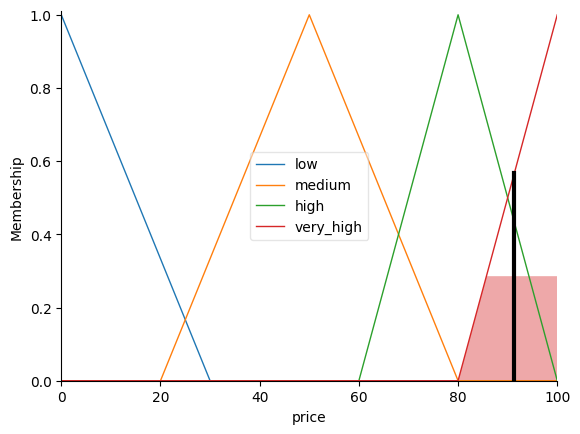

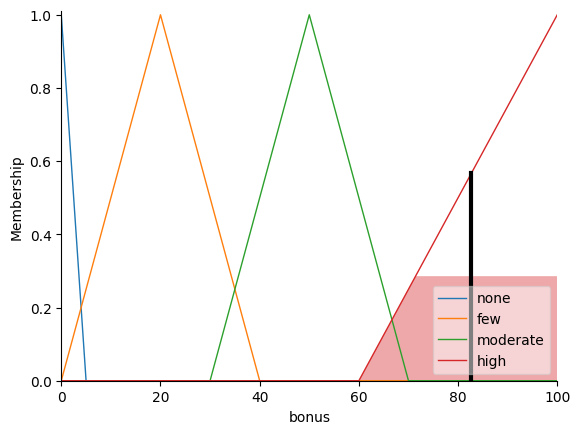

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl


khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
thoi_tiet = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
danh_gia = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
dung_gio = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

gia_ca = ctrl.Consequent(np.arange(0, 101, 1), 'price')
diem_thuong = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')


# Khoảng cách
khoang_cach['short'] = fuzz.trimf(khoang_cach.universe, [0, 0, 3])
khoang_cach['medium'] = fuzz.trimf(khoang_cach.universe, [2, 4.5, 7])
khoang_cach['long'] = fuzz.trimf(khoang_cach.universe, [6, 13, 20])
khoang_cach['very_long'] = fuzz.trimf(khoang_cach.universe, [15, 50, 50])

# Giao thông
giao_thong['low'] = fuzz.trimf(giao_thong.universe, [0, 0, 30])
giao_thong['medium'] = fuzz.trimf(giao_thong.universe, [20, 45, 70])
giao_thong['high'] = fuzz.trimf(giao_thong.universe, [60, 100, 100])

# Nhu cầu
nhu_cau['low'] = fuzz.trimf(nhu_cau.universe, [0, 0, 30])
nhu_cau['medium'] = fuzz.trimf(nhu_cau.universe, [20, 45, 70])
nhu_cau['high'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

# Thời tiết
thoi_tiet['good'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 4])
thoi_tiet['moderate'] = fuzz.trimf(thoi_tiet.universe, [3, 5, 7])
thoi_tiet['bad'] = fuzz.trimf(thoi_tiet.universe, [6, 10, 10])

# Đánh giá khách hàng
danh_gia['poor'] = fuzz.trimf(danh_gia.universe, [1, 1, 2.5])
danh_gia['average'] = fuzz.trimf(danh_gia.universe, [2.5, 3.25, 4.0])
danh_gia['good'] = fuzz.trimf(danh_gia.universe, [3.5, 5.0, 5.0])

# Đúng giờ
dung_gio['late'] = fuzz.trimf(dung_gio.universe, [0, 0, 50])
dung_gio['on_time'] = fuzz.trimf(dung_gio.universe, [40, 60, 80])
dung_gio['early'] = fuzz.trimf(dung_gio.universe, [70, 100, 100])

# --- Đầu ra Giá vé ---
gia_ca['low'] = fuzz.trimf(gia_ca.universe, [0, 0, 30])
gia_ca['medium'] = fuzz.trimf(gia_ca.universe, [20, 50, 80])
gia_ca['high'] = fuzz.trimf(gia_ca.universe, [60, 80, 100])
gia_ca['very_high'] = fuzz.trimf(gia_ca.universe, [80, 100, 100])

# --- Đầu ra Điểm thưởng ---
diem_thuong['none'] = fuzz.trimf(diem_thuong.universe, [0, 0, 5])
diem_thuong['few'] = fuzz.trimf(diem_thuong.universe, [0, 20, 40])
diem_thuong['moderate'] = fuzz.trimf(diem_thuong.universe, [30, 50, 70])
diem_thuong['high'] = fuzz.trimf(diem_thuong.universe, [60, 100, 100])


rule1 = ctrl.Rule(khoang_cach['short'] & giao_thong['low'] & nhu_cau['low'], gia_ca['low'])
rule2 = ctrl.Rule(khoang_cach['short'] & giao_thong['medium'] & nhu_cau['high'], gia_ca['medium'])
rule3 = ctrl.Rule(khoang_cach['medium'] & giao_thong['high'] & nhu_cau['high'], gia_ca['high'])
rule4 = ctrl.Rule(khoang_cach['long'] & giao_thong['medium'] & thoi_tiet['good'], gia_ca['medium'])
rule5 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & thoi_tiet['bad'], gia_ca['very_high'])
rule6 = ctrl.Rule(khoang_cach['very_long'] & giao_thong['high'] & nhu_cau['high'], gia_ca['very_high'])
rule7 = ctrl.Rule(khoang_cach['medium'] & giao_thong['low'] & nhu_cau['low'], gia_ca['medium'])
rule8 = ctrl.Rule(khoang_cach['short'] & giao_thong['high'] & thoi_tiet['bad'], gia_ca['high'])
rule9 = ctrl.Rule(khoang_cach['very_long'] & thoi_tiet['bad'], gia_ca['very_high'])
rule10 = ctrl.Rule(khoang_cach['medium'] & giao_thong['medium'] & thoi_tiet['moderate'], gia_ca['medium'])

rule11 = ctrl.Rule(danh_gia['good'] & dung_gio['early'], diem_thuong['high'])
rule12 = ctrl.Rule(danh_gia['average'] & dung_gio['on_time'], diem_thuong['moderate'])
rule13 = ctrl.Rule(danh_gia['poor'] & dung_gio['late'], diem_thuong['none'])
rule14 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & dung_gio['on_time'], diem_thuong['high'])
rule15 = ctrl.Rule(khoang_cach['medium'] & giao_thong['medium'] & danh_gia['good'], diem_thuong['moderate'])
rule16 = ctrl.Rule(danh_gia['poor'] & dung_gio['late'], diem_thuong['none'])
rule17 = ctrl.Rule(khoang_cach['very_long'] & thoi_tiet['bad'] & danh_gia['good'], diem_thuong['high'])
rule18 = ctrl.Rule(khoang_cach['short'] & danh_gia['average'] & dung_gio['on_time'], diem_thuong['few'])
rule19 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & dung_gio['late'], diem_thuong['few'])
rule20 = ctrl.Rule(khoang_cach['medium'] & thoi_tiet['moderate'] & danh_gia['good'], diem_thuong['moderate'])



grab_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
                                rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])


grab_simulation = ctrl.ControlSystemSimulation(grab_ctrl)

grab_simulation.input['distance'] = 8
grab_simulation.input['traffic'] = 80
grab_simulation.input['demand'] = 75
grab_simulation.input['weather'] = 8
grab_simulation.input['rating'] = 4.8
grab_simulation.input['punctuality'] = 50


grab_simulation.compute()


print("==== KẾT QUẢ TÍNH TOÁN HỆ THỐNG GRAB-BIKE ====")
print(f"Mức giá vé đề xuất: {grab_simulation.output['price']:.2f} % (0=Rất thấp, 100=Rất cao)")
print(f"Điểm thưởng cho tài xế: {grab_simulation.output['bonus']:.2f} điểm")


gia_ca.view(sim=grab_simulation)
diem_thuong.view(sim=grab_simulation)


**2.12**

Muc chiet khau de xuat:46.50 %


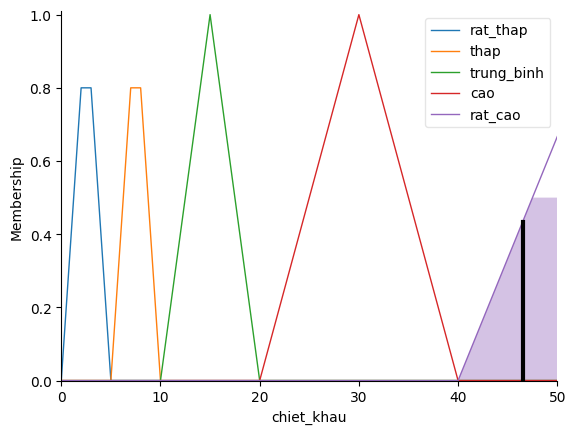

In [3]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

# Biến đầu vào
danh_gia = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'danh_gia')
doanh_so = ctrl.Antecedent(np.arange(0, 101, 1), 'doanh_so')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')
mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'mua_vu')
doi_thu = ctrl.Antecedent(np.arange(0, 101, 1), 'doi_thu')

# Biến đầu ra
chiet_khau = ctrl.Consequent(np.arange(0, 51, 1), 'chiet_khau')

# Định nghĩa tập mờ
danh_gia['thap'] = fuzzy.trimf(danh_gia.universe, [0, 0, 4.0])
danh_gia['trung_binh'] = fuzzy.trimf(danh_gia.universe, [4.0, 4.25, 4.5])
danh_gia['cao'] = fuzzy.trimf(danh_gia.universe, [4.5, 5, 5])

for bien in [doanh_so, loi_nhuan, mua_vu, doi_thu]:
    bien['thap'] = fuzzy.trimf(bien.universe, [0, 0, 50])
    bien['trung_binh'] = fuzzy.trimf(bien.universe, [20, 50, 80])
    bien['cao'] = fuzzy.trimf(bien.universe, [80, 100, 100])

# Tập mờ của chiết khấu
chiet_khau['rat_thap'] = fuzzy.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['thap'] = fuzzy.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzzy.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['cao'] = fuzzy.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao'] = fuzzy.trimf(chiet_khau.universe, [40, 55, 70])

# thiet lap cac luat mo
luat1 = ctrl.Rule(danh_gia['cao'] & doanh_so['cao'] & loi_nhuan['cao'], chiet_khau['rat_thap'])
luat2 = ctrl.Rule(danh_gia['thap'] & doanh_so['thap'] & loi_nhuan['cao'], chiet_khau['cao'])
luat3 = ctrl.Rule(mua_vu['cao'] & doi_thu['cao'], chiet_khau['rat_cao'])
luat4 = ctrl.Rule(danh_gia['trung_binh'] & doanh_so['trung_binh'] & loi_nhuan['trung_binh'], chiet_khau['trung_binh'])
luat5 = ctrl.Rule(doi_thu['thap'] & loi_nhuan['thap'] & doanh_so['cao'], chiet_khau['rat_thap'])
luat6 = ctrl.Rule(danh_gia['thap'] & mua_vu['thap'], chiet_khau['trung_binh'])
luat7 = ctrl.Rule(doanh_so['thap'] & loi_nhuan['thap'], chiet_khau['cao'])

# khoi tao he thong dieu khien
he_thong = ctrl.ControlSystem([luat1, luat2, luat3, luat4, luat5, luat6, luat7])
mo_phong = ctrl.ControlSystemSimulation(he_thong)

# nap du lieu dau vao cho tinh huong
mo_phong.input['danh_gia'] = 4.3
mo_phong.input['doanh_so'] = 50
mo_phong.input['loi_nhuan'] = 20
mo_phong.input['mua_vu'] = 90
mo_phong.input['doi_thu'] = 90

# tinh toan va xuat ket qua
mo_phong.compute()
print(f'Muc chiet khau de xuat:{mo_phong.output['chiet_khau']:.2f} %')
chiet_khau.view(sim=mo_phong)

**2.13**

Muc chiet khau de xuat: 15.00 %


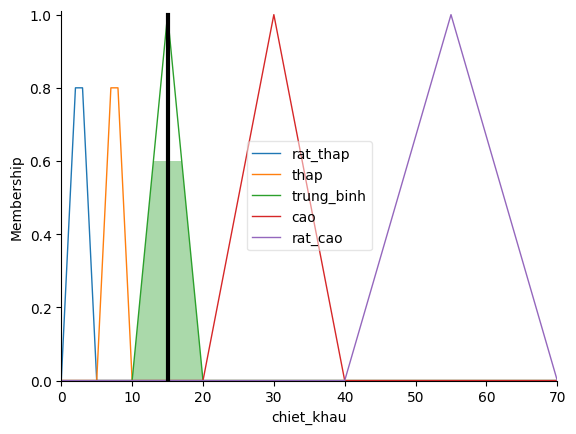

In [4]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Khai báo các biến đầu vào (Antecedents) và đầu ra (Consequent)
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
ap_luc_canh_tranh = ctrl.Antecedent(np.arange(0, 101, 1), 'ap_luc_canh_tranh')
uy_tin = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'uy_tin')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_loi_nhuan')
mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'mua_vu')

# Chiết khấu tối đa 70% theo mô tả "Rất cao"
chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

# 2. Định nghĩa tập mờ cho các biến đầu vào (0 - 100)
for bien in [nhu_cau, ap_luc_canh_tranh, bien_loi_nhuan, mua_vu]:
    bien['thap'] = fuzzy.trimf(bien.universe, [0, 0, 50])
    bien['trung_binh'] = fuzzy.trimf(bien.universe, [25, 50, 75])
    bien['cao'] = fuzzy.trimf(bien.universe, [50, 100, 100])

# Định nghĩa riêng nhãn "khong_co" cho mùa vụ
mua_vu['khong_co'] = fuzzy.trimf(mua_vu.universe, [0, 0, 30])

# Định nghĩa tập mờ cho uy tín cửa hàng (0 - 5 sao)
uy_tin['thap'] = fuzzy.trimf(uy_tin.universe, [0, 0, 4])
uy_tin['trung_binh'] = fuzzy.trimf(uy_tin.universe, [4, 4.25, 4.5])
uy_tin['cao'] = fuzzy.trimf(uy_tin.universe, [4.5, 5, 5])

# 3. Định nghĩa tập mờ cho chiết khấu đầu ra (0 - 70%)
chiet_khau['rat_thap'] = fuzzy.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['thap'] = fuzzy.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzzy.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['cao'] = fuzzy.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao'] = fuzzy.trimf(chiet_khau.universe, [40, 55, 70])

# 4. Thiết lập các luật mờ (Rules)
l1 = ctrl.Rule(nhu_cau['cao'] & ap_luc_canh_tranh['thap'] & bien_loi_nhuan['thap'], chiet_khau['rat_thap'])
l2 = ctrl.Rule(nhu_cau['thap'] & ap_luc_canh_tranh['cao'] & bien_loi_nhuan['cao'], chiet_khau['cao'])
l3 = ctrl.Rule(uy_tin['cao'] & bien_loi_nhuan['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])
l4 = ctrl.Rule(ap_luc_canh_tranh['cao'] & mua_vu['cao'] & bien_loi_nhuan['cao'], chiet_khau['rat_cao'])
l5 = ctrl.Rule(uy_tin['thap'] & nhu_cau['trung_binh'] & bien_loi_nhuan['thap'], chiet_khau['trung_binh'])
l6 = ctrl.Rule(nhu_cau['cao'] & mua_vu['khong_co'] & ap_luc_canh_tranh['thap'], chiet_khau['rat_thap'])
# Luật quan trọng nhất cho tình huống đồng hồ xa xỉ
l7 = ctrl.Rule(bien_loi_nhuan['cao'] & ap_luc_canh_tranh['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])

# 5. Khởi tạo hệ thống điều khiển và mô phỏng
he_thong = ctrl.ControlSystem([l1, l2, l3, l4, l5, l6, l7])
mo_phong = ctrl.ControlSystemSimulation(he_thong)

# 6. Nạp dữ liệu đầu vào cho tình huống: Đồng hồ xa xỉ thủ công
mo_phong.input['nhu_cau'] = 90
mo_phong.input['ap_luc_canh_tranh'] = 50
mo_phong.input['uy_tin'] = 4.2
mo_phong.input['bien_loi_nhuan'] = 80
mo_phong.input['mua_vu'] = 90

# 7. Tính toán và hiển thị kết quả
mo_phong.compute()

# Hiển thị kết quả ra màn hình
print(f'Muc chiet khau de xuat: {mo_phong.output["chiet_khau"]:.2f} %')

# Hiển thị đồ thị kết quả
chiet_khau.view(sim=mo_phong)
plt.show()

**2.14**

   KẾT QUẢ TỪ HỆ THỐNG LOGIC MỜ
1. Số lượng đơn đề xuất gom (Combine): 8.19 đơn (Làm tròn: 8 đơn)
2. Điểm mức độ ưu tiên (Priority)    : 5.00 / 10 điểm


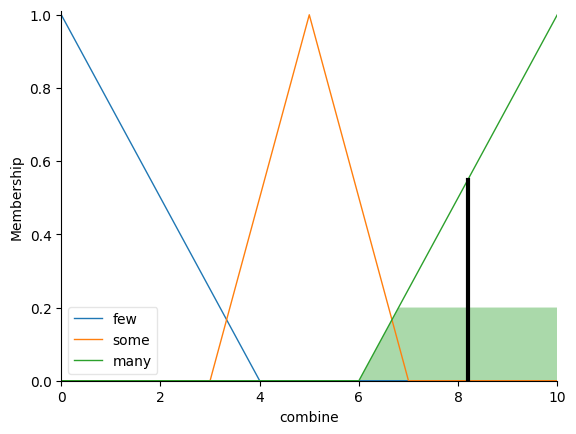

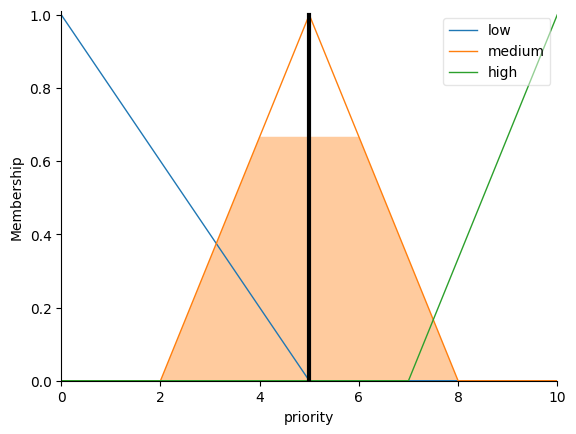

In [8]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

universe_scale = np.arange(0, 11, 1)

density = ctrl.Antecedent(universe_scale, 'density')          # Mật độ đơn
urgency = ctrl.Antecedent(universe_scale, 'urgency')          # Độ khẩn cấp
driver_load = ctrl.Antecedent(universe_scale, 'load')         # Tải trọng tài xế
traffic = ctrl.Antecedent(universe_scale, 'traffic')          # Tình trạng giao thông
profit = ctrl.Antecedent(universe_scale, 'profit')            # Lợi nhuận

combine = ctrl.Consequent(universe_scale, 'combine')
priority = ctrl.Consequent(universe_scale, 'priority')

for var in [density, urgency, driver_load, traffic, profit, priority]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])          # Thấp / Ít
    var['medium'] = fuzz.trimf(var.universe, [2, 5, 8])       # Trung bình
    var['high'] = fuzz.trimf(var.universe, [7, 10, 10])       # Cao / Nhiều


combine['few'] = fuzz.trimf(combine.universe, [0, 0, 4])      # Ít đơn
combine['some'] = fuzz.trimf(combine.universe, [3, 5, 7])     # Vài đơn
combine['many'] = fuzz.trimf(combine.universe, [6, 10, 10])   # Nhiều đơn

rule1 = ctrl.Rule(density['high'] & driver_load['low'] & traffic['low'], combine['many'])
rule2 = ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine['some'])
rule3 = ctrl.Rule(driver_load['high'] & density['high'] & profit['medium'], combine['some'])
rule4 = ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['few'])
rule5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['few'])
rule6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])
rule7 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])
rule8 = ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])

delivery_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)


delivery_sim.input['density'] = 8       # Mật độ
delivery_sim.input['urgency'] = 5       # Khẩn cấp
delivery_sim.input['load'] = 2          # Tải trọng
delivery_sim.input['traffic'] = 4       # Giao thông
delivery_sim.input['profit'] = 5        # Lợi nhuận

delivery_sim.compute()

print("   KẾT QUẢ TỪ HỆ THỐNG LOGIC MỜ")

out_combine = delivery_sim.output['combine']
out_priority = delivery_sim.output['priority']

print(f"1. Số lượng đơn đề xuất gom (Combine): {out_combine:.2f} đơn (Làm tròn: {round(out_combine)} đơn)")
print(f"2. Điểm mức độ ưu tiên (Priority)    : {out_priority:.2f} / 10 điểm")
combine.view(sim = delivery_sim)
priority.view(sim = delivery_sim)